# Assignment 1 - Medical Insurance Cost Prediction

**Name:** Aarushi
**Topic:** Medical Insurance Cost Prediction using Multiple Linear Regression
**Dataset:** [Medical Cost Personal Insurance Dataset - Kaggle](https://www.kaggle.com/datasets/mirichoi0218/insurance)

## Task 1: Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.shape

(1338, 7)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


**Numerical features:** age, bmi, children

**Categorical features:** sex, smoker, region

**Target variable:** charges

## Task 2: Data Preprocessing

In [5]:
# checking for missing values
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


No missing values in any column, so no imputation needed.

In [7]:
# encoding categorical variables
df_encoded = df.copy()

df_encoded['sex'] = df_encoded['sex'].map({'male': 0, 'female': 1})
df_encoded['smoker'] = df_encoded['smoker'].map({'no': 0, 'yes': 1})

df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True)
df_encoded.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [8]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(1070, 8) (268, 8)


## Task 3: Model Development

In [9]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
coeff_df = pd.DataFrame(lr.coef_, X.columns, columns=['Coefficient'])
coeff_df

,Coefficient
age,256.975706
sex,18.591692
bmi,337.092552
children,425.278784
smoker,23651.128856
region_northwest,-370.677326
region_southeast,-657.864297
region_southwest,-809.799354


In [11]:
print('Intercept:', lr.intercept_)

Intercept: -11949.810741967713


In [12]:
y_pred = lr.predict(X_test)
y_pred[:10]

array([ 8969.55027444,  7068.74744287, 36858.41091155,  9454.67850053,
       26973.17345656, 10864.11316424,   170.28084136, 16903.45028662,
        1092.43093614, 11218.34318352])

## Task 4: Model Evaluation

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('MAE:', mae)
print('MSE:', mse)
print('RMSE:', rmse)
print('R2 Score:', r2)

MAE: 4181.19447375365
MSE: 33596915.85136146
RMSE: 5796.2846592762735
R2 Score: 0.7835929767120723


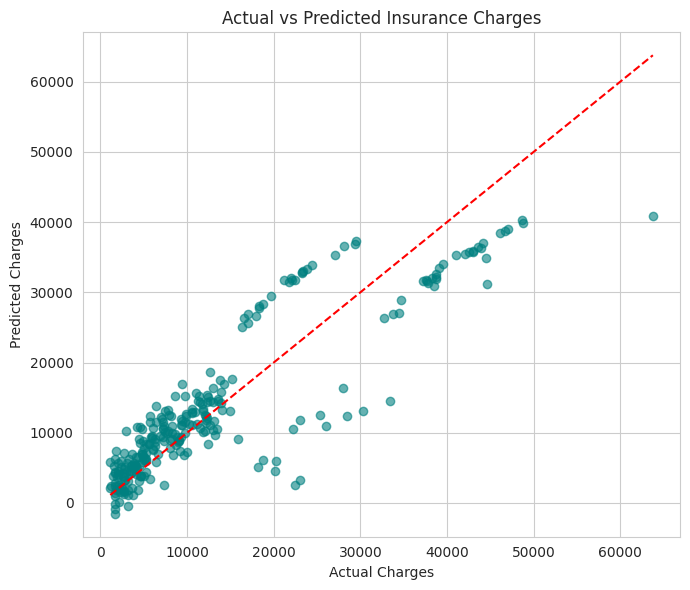

In [14]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Insurance Charges')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')
plt.show()

### Observations

1. The model gives an R² score of around 0.78, meaning it explains about 78% of the variation in insurance charges - a decent fit but not perfect.
2. Smoker status has by far the largest coefficient, so smokers are charged much higher premiums than non-smokers, everything else being equal.
3. Looking at the scatter plot, most points follow the diagonal reasonably well for lower charge values, but the model underpredicts for a cluster of high-charge customers (likely smokers with high BMI), showing that the relationship isn't fully linear.

## Task 5: Conclusion

This project used a Multiple Linear Regression model to predict medical insurance charges based on age, sex, BMI, number of children, smoking status, and region. The model achieved an R2 score of approximately 0.78 on the test set, showing a reasonably good fit. Smoking status turned out to be the strongest predictor of charges by a wide margin, followed by BMI and age, which matches real-world expectations since smoking and obesity are known health risk factors that insurers price for. Region and sex had a comparatively small effect on the predicted charges.

One key limitation of Linear Regression here is that it assumes a linear relationship between features and charges, but the actual relationship, especially between smoking, BMI, and charges, appears non-linear. This causes the model to underpredict costs for high-risk individuals, and a non-linear model like Random Forest could likely capture these interactions better.